- To download this notebook, click the download icon in the toolbar above and select the .ipynb format.  
- For any questions or comments, please open an issue on the [c4dynamics issues page](https://github.com/C4dynamics/C4dynamics/issues).  


# Object Tracking

In the following set of examples, we run a Kalman filter 
to demonstrate smooth and continuous tracking of vehicles 
across video frames. 

## Setup 


The process model assumes linear motion with constant velocity 
where the system matrix


$$
A = \begin{bmatrix}
        0   &   0   &   0   &   0   &   1   &   0   \\
        0   &   0   &   0   &   0   &   0   &   1   \\
        0   &   0   &   0   &   0   &   0   &   0   \\
        0   &   0   &   0   &   0   &   0   &   0   \\
        0   &   0   &   0   &   0   &   0   &   0   \\
        0   &   0   &   0   &   0   &   0   &   0 
      \end{bmatrix}  
$$  

represents the linear ordinary differential equations: 

$$
  \dot{x} = v_x  \\
  \dot{y} = v_y  \\
  \dot{w}  = 0    \\
  \dot{h}  = 0    \\
  \dot{v}_x = 0  \\
  \dot{v}_y = 0  
$$


It is therefore obvious that 
the system state vector is given by:


$$
x = \begin{bmatrix}
x \\
y \\
w \\
h \\
v_x \\
v_y 
\end{bmatrix}
$$

Where $x, y$ are pixel coordinates, $w, h$ are bounding box dimensions, and $v_x, v_y$ are velocities. 



As a measurement for the vehicle position and 
box size, we use the `YOLOv3` object detection model.
`YOLOv3` is incorporated in the c4dynamics' class 
[yolov3](https://c4dynamics.github.io/C4dynamics/api/detectors.yolov3.html). 
The method [detect](https://c4dynamics.github.io/C4dynamics/api/generated/yolov3/c4dynamics.detectors.yolo3_opencv.yolov3.detect.html)
returns a [pixelpoint](https://c4dynamics.github.io/C4dynamics/api/states.lib.pixelpoint.html#c4dynamics.states.lib.pixelpoint.pixelpoint) instance for each detected object: 

In [2]:
import sys 
sys.path.append(r'..\..\..')
from c4dynamics import pixelpoint 
print(pixelpoint())

[ x  y  w  h ]


That is, the measurements fed into the Kalman filter are 
directly the first four variables of the state. 

From this, we can directly derive the 
measurement matrix that forms the 
relation between the measurements and the state:


$$
  C = \begin{bmatrix}
        1 & 0 & 0 & 0 & 0 & 0 \\
        0 & 1 & 0 & 0 & 0 & 0 \\
        0 & 0 & 1 & 0 & 0 & 0 \\
        0 & 0 & 0 & 1 & 0 & 0 
      \end{bmatrix}  
$$

This also implies that the system is observable but to be on the safe side 
let's examine the rank of the observability matrix.

First, import the required packages for the code 
in this snippet and the ones that follow: 


In [3]:
import c4dynamics as c4d 
from matplotlib import pyplot as plt 
from scipy.linalg import expm 
import numpy as np 
import cv2 

Let's define the system matrices:

In [4]:
A = np.zeros((6, 6))
A[0, 4] = A[1, 5] = 1
C = np.zeros((4, 6))
C[0, 0] = C[1, 1] = C[2, 2] = C[3, 3] = 1

Now, build the observability matrix and check the rank: 

In [5]:
obsv = C
n = len(A)
for i in range(1, n):
  obsv = np.vstack((obsv, C @ np.linalg.matrix_power(A, i)))
rank = np.linalg.matrix_rank(obsv)
c4d.cprint(f'The system is observable (rank = n = {n}).' if rank == n else 'The system is not observable (rank = {rank), n = {n}).', 'y')

The system is observable (rank = n = 6).


In each estimation, the `box` function converts the state coordinates to rectangle 
corners to draw a bounding box: 

In [6]:
def box(X):
    # top left
    xtl = int(X[0] - X[2] / 2)
    ytl = int(X[1] - X[3] / 2)
    # bottom right 
    xbr = int(X[0] + X[2] / 2)
    ybr = int(X[1] + X[3] / 2)
    return [(xtl, ytl), (xbr, ybr)]

The video in the following examples is used 
by kind permission of [Abed Ismail](https://www.pexels.com/@abed-ismail). 
The video can be fetched using the c4dynamics' 
[datasets](https://c4dynamics.github.io/C4dynamics/api/Datasets.html) module: 


In [7]:
vidpath = c4d.datasets.video('drifting_car')

Fetched successfully


Video setup: 


In [8]:
video_cap = cv2.VideoCapture(vidpath)
fps = video_cap.get(cv2.CAP_PROP_FPS)
dt_frame = 1 / fps 


Let's take the prediction rate to be twice the frames rate:


In [9]:
dt = dt_frame / 2 

## Steady-state mode 


As start, let's take the noise matrices ($Q_k$ of the process, and 
$R_k$ of the measurement) as constant. Since the system is 
$LTI$ (linear time invariant), the Kalman gain ($K$) and consequently the estimation covariance matrix 
($P$) are computed once and are constant ('steady-state') for the entire run-time.

  
Dynamics model and noise matrices: 




 TODO im not sure anymore its needed to start with cont. 
just add the cont matrices and explain why the covariances are the same.
 TODO my conclusion from all this is that it's not an example.
its a program. examples are short and straright froward and not 
entail all this intro. 
 maybe to separate between disc and cont only in the 
sys matrices but in the covariance to leave it to the user consid. 
3. instead of messing with all this maybe just show simple things.
things that relevant to the user and not to the fresh class studegnt of eng. 
focus on seeing the state of the kalman. of initializaing. of storging. 
much more important for this class. and move this example to programs==usecases. 


In [10]:
# process dynamics 
A = np.zeros((6, 6))
A[0, 4] = A[1, 5] = 1
F = expm(A * dt)
# measurement model 
H = np.zeros((4, 6))
H[0, 0] = H[1, 1] = H[2, 2] = H[3, 3] = 1


From some exprerience with the objects detection model it is 
a fair evaulation to give the model an average error of 4 pixels 
both for position and box size. 
Assuming that the uncertainty TODO ??

The selection of the noise errors: 


In [11]:
# covariance matrices 
process_std = measure_std = 4 
Q = np.eye(6) * process_std**2   # process_noise
R = np.eye(4) * measure_std**2   # measure_noise


indicates that the errors associated with the process 
and the errors associated with the measurement 
have equal weight (a standard deviation of `4`, units depend on the
variable). 





Kalman object definition. 
The initialization includes the state variables, mode, and matrices:


In [14]:
kf = c4d.filters.kalman({'x': 0, 'y': 0, 'w': 0, 'h': 0, 'vx': 0, 'vy': 0}
                      , steadystate = True, F = F, H = H, Q = Q, R = R)



Object detection model: 


In [15]:
yolo3 = c4d.detectors.yolov3()

Fetched successfully



  
Main loop. The first step, prediction, occurs in every cycle. 
The second step, update (correction), occurs when a car detection is made:   


In [16]:
t = 0
while video_cap.isOpened():
  t += dt
  # predict
  kf.predict()
  ret, frame = video_cap.read()
  if not ret: break
  d = yolo3.detect(frame)
  if d and d[0].class_id == 'car': 
    # correct 
    kf.update(d[0].X)
    kf.detect = d 
    kf.storeparams('detect', t)
  kf.store(t)
  _ = cv2.rectangle(frame, box(kf.X)[0], box(kf.X)[1], [0, 255, 0], 2)  
  cv2.imshow('', frame) 
  cv2.waitKey(10)
cv2.destroyAllWindows()


detect is not a scalar. Only first item is stored
To suppress c4dynamics' warnings, run: import warnings, import c4dynamics as c4d, warnings.simplefilter('ignore', c4d.c4warn)
 (File: z:\Dropbox\c4dynamics\docs\source\programs\..\..\..\c4dynamics\states\state.py, Line: 633)




.. figure:: /programs/figures/driftcar/drifting_car.gif




## Plotting 


The :meth:`plot <c4dynamics.states.state.state.plot>` 
method of the superclass :class:`state <c4dynamics.states.state.state>` 
allows direct generation of the state variables. 
The plot of the position `x` is given by: 


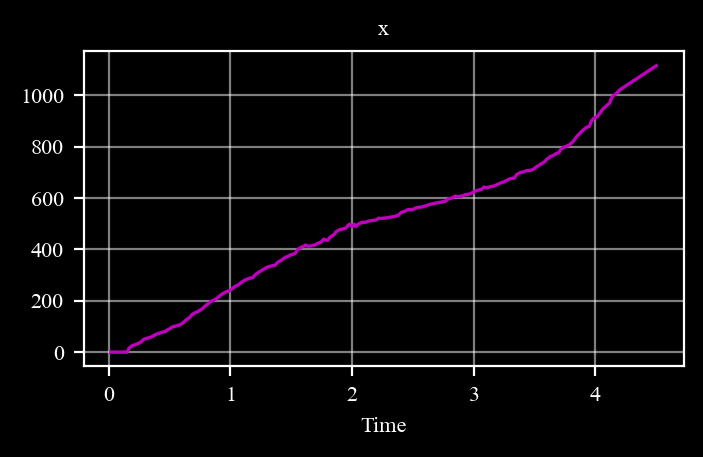

In [17]:
kf.plot('x')
plt.show()


.. figure:: /programs/figures/driftcar/steadystate_x.png
         

     


Now, since we also stored the detections (using 
:meth:`storeparams <c4dynamics.states.state.state.storeparams>`), 
we can add the detection marks on the state line: 



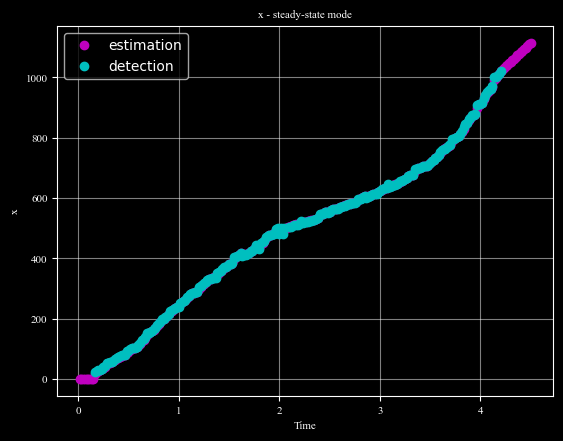

In [18]:
plt.plot(*kf.data('x'), 'om', label = 'estimation')
plt.gca().plot(kf.data('detect')[0], np.vectorize(lambda d: d.x if isinstance(d, c4d.pixelpoint) else np.nan)(kf.data('detect')[1]), 'co', label = 'detection')
c4d.plotdefaults(plt.gca(), 'x - steady-state mode', 'Time', 'x', 8)
plt.legend()


  
The first argument (:code:`kf.data('detect')[0]`) in the third line is 
just the time series of the detections at the storing samples. 
The second argument uses numpy's `vectorize` to extract the 
`x` field from the detection data. 



In [19]:
plt.show()

.. figure:: /programs/figures/driftcar/steadystate_detections.png



By focusing on an arbitrary region the operation of the prediction is revealed. 
While the frame rate is 30 frames per second, the main loop runs 60 frames 
per second. 
For every cycle where no image is taken, the prediction 
estimates the object's position based on the dynamics model: 



.. figure:: /programs/figures/driftcar/steadystate_detections_zoom.png




This is true also for the edges where the object is outside the frame and 
wherever the detection model fails to identify the object in the frame. 
In such cases, the Kalman filter provides 
an optimal estimation of the objects' current state. 
  

By default, kalman's :meth:`store` stores also samples of the 
main diagonal of `P`, the covariance matrix. Each element 
is named `Pii`, where `i` is the index of the variable in 
the state. Here `x` is the first variable:


In [20]:
print(kf)

[ x  y  w  h  vx  vy ]



  
Then extracting the standard deviations of `x` from the storage 
is possible by: 
  


In [21]:
t_std, x_std = kf.data('P00')[0], np.sqrt(kf.data('P00')[1])



As before, the first argument provides the 
time series for the samples of `P00`. 
In the second argument, we take 
square root of the values of `P00` to convert the variances to standard deviations. 

The standard deviations represent the estimation error. 
It is therefore convinent to plot them alongside the state variables: 



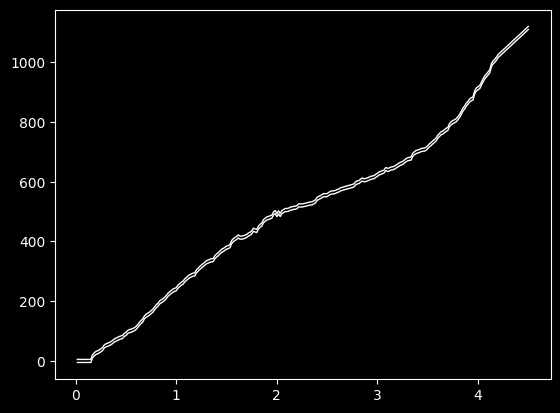

In [22]:
plt.gca().plot(t_std, kf.data('x')[1] - x_std, 'w', linewidth = 1, label = 'std')
plt.gca().plot(t_std, kf.data('x')[1] + x_std, 'w', linewidth = 1)


  
.. figure:: /programs/figures/driftcar/steadystate_std.png




The nature of the steady-state mode is conveyed here 
by the constant variance, which represents the error in the variable 






## Discrete system 


In the previous example, we ran the filter in steady-state mode.
That means that the estimation error (the state covariance matrix `P`) 
is calculated once and remains
constant during the filter runtime. 

This mode is enabled when the covariance matrices 
that describe the process noise (:math:`Q` or :math:`Q_k`) 
and the measurement noise (:math:`R` or :math:`R_k`) are 
themselves constant. 

However, when the noise matrices are time-varying,  
steady-state mode is not feasible. 

The previous case may be improved by adjusting 
the process noise matrix :math:`Q_k`.


Let's re-examine the plot of the x-coordinate over time: 



.. figure:: /programs/figures/driftcar/steadystate_x.png



The dynamics model assumes linear motion.
However, the actual motion in the x-coordinate 
is approximately linear up to `4s`, but then 
changes direction, continues linearly until 
`7s`, and changes direction again until exit the frame. 

In fact, in the vicinity of `t = 4s`, there is a 
significant gap between the 
estimation (magenta) and the detection measures (cyan): 



.. figure:: /programs/figures/driftcar/steadystate_std_zoom.png



The reason is that the filter relies on the process model 
just as it trusts the measurements and therefore 
averages the predictons and the measurements. 

Recall that we used :math:`Q, R` a diagonal matrices with 
a standard deviation of `4`:  


In [23]:
process_std = measure_std = 4 
Q = np.eye(6) * process_std**2 
R = np.eye(4) * measure_std**2 


To address the gap between the estimation and the detections, 
let's make the process noise :math:`Q` less 
tight around `t = 4s`:


$$
  std_{process} = \begin{cases} 
                8 & \text{3.9 < t < 4.15} \\
                4 & \text{otherwise}
                \end{cases}
$$

Namely, at `t = 4s`, the process error is high, and the filter 
should place less weight on the process model.

In fact, since the filter recalculates the covariance at each time step, 
it is better to reduce :math:`R` and :math:`Q` by a factor compared 
to the steady state mode values. Here, the factor is set to `0.5`. 


In [24]:
noisefactor = 0.5
Q *= noisefactor
R *= noisefactor


The filter initialization is similar to the previous case, 
with the steady-state flag omitted.

Discrete system kalman initalization: 


In [25]:
kf = c4d.filters.kalman({'x': 0, 'y': 0, 'w': 0, 'h': 0, 'vx': 0, 'vy': 0}
                          , P0 = Q, F = F, H = H, Q = Q, R = R)



The main loop is only modified to include the change in :math:`Q_k`: 



In [26]:
t = 0
# main loop       
while video_cap.isOpened():
  kf.store(t)
  t += dt
  if t > 3.9 and t < 4.15:
    Q = np.eye(6) * 8**2 * noisefactor
  else: 
    Q = np.eye(6) * 4**2 * noisefactor
  kf.predict(Q = Q)
  if round(t / dt_frame, 1) % 1 >= 1e-10: continue   
  # camera cycle:
  ret, frame = video_cap.read()
  if not ret: break
  d = yolo3.detect(frame)
  if d and (d[0].class_id == 'car'):  
    kf.update(d[0].X)
    kf.detect = d 
    kf.storeparams('detect', t)
  cv2.rectangle(frame, box(kf.X)[0], box(kf.X)[1], [0, 255, 0], 2) 
  cv2.imshow('', frame)
  cv2.waitKey(10)
cv2.destroyAllWindows()


Now, the measures should respond stronger 
when the car changes direction at :math:`t \\approx 4s`: 



.. figure:: /programs/figures/driftcar/discrete_std_zoom.png


## Continuous system 



We can achieve the same result by running continuous system. 

The respective system 

Let: 



This however not suprising, as the class and its methods converts any input 
system to a discerte represnation according to the inverse of the equations above 
and run the filter. 